# ARIMA — An Illustrated Tour

> The **ARIMA(p, d, q)** family combines **AR**(autoregressive), **I**(differencing) and **MA**(moving-average) terms. After differencing $d$ times to get a stationary series, the residual is modelled as a linear function of past values and past errors.

---

**What we cover:**
- Stationarity & differencing
- ACF / PACF — the diagnostic plots that pick $p$ and $q$
- Fitting a synthetic AR(2) and MA(2)
- A real-ish trend + seasonality series → forecast with 95 % band
- Residual diagnostics

## The picture — ARIMA = AR (memory) + I (differencing) + MA (shock smoothing)

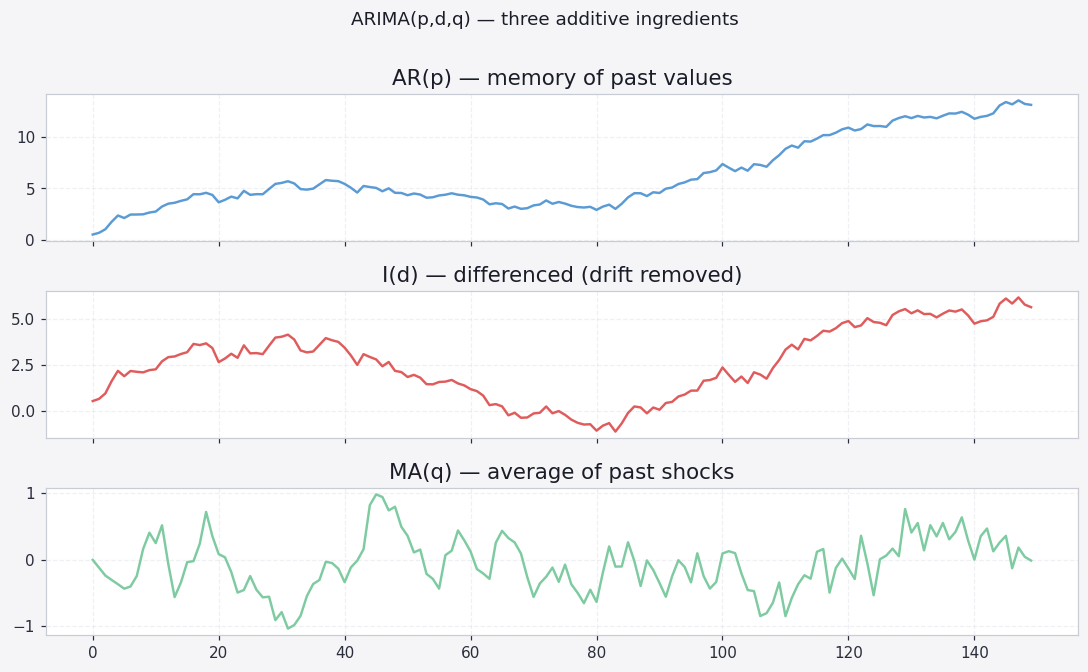

In [1]:
# (schematic — drawn from smooth curves, not measured)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrow, FancyBboxPatch, Ellipse, Rectangle, Circle, FancyArrowPatch
plt.rcParams.update({
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':14,'axes.labelsize':12,
    'legend.facecolor':'#ffffff','legend.edgecolor':'#c8ccd4','figure.dpi':110,
})
P = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']
rng = np.random.RandomState(0)
t = np.arange(150); trend = 0.05*t
ar = np.cumsum(rng.randn(150))*0.3
ma = np.convolve(rng.randn(160), np.ones(5)/5, mode='valid')[:150]
fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
for ax, y, c, lab in zip(axes, [trend+ar, ar, ma],
                          [P[0], P[1], P[3]],
                          ['AR(p) — memory of past values',
                           'I(d) — differenced (drift removed)',
                           'MA(q) — average of past shocks']):
    ax.plot(t, y, color=c, lw=1.6); ax.set_title(lab); ax.grid(True)
fig.suptitle('ARIMA(p,d,q) — three additive ingredients', y=1.01)
plt.tight_layout(); plt.show()


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

PLT_STYLE = {
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':17,'axes.labelsize':13,
    'xtick.labelsize':11,'ytick.labelsize':11,'legend.fontsize':11,'legend.facecolor':'#ffffff',
    'legend.edgecolor':'#c8ccd4','figure.dpi':120,
}
plt.rcParams.update(PLT_STYLE)
C0='#5b9bd5'; C1='#e05c5c'; CB='#f4b942'; CM='#7ecba1'

rng = np.random.default_rng(0)
n = 240
t = np.arange(n)
trend = 0.05 * t
seasonal = 1.5 * np.sin(2*np.pi*t/12)
noise_path = np.zeros(n)
for i in range(1, n):
    noise_path[i] = 0.7 * noise_path[i-1] + rng.normal(0, 0.6)
y = trend + seasonal + noise_path + 5.0
print('Series length:', n)

Series length: 240


---
## Stationarity & Differencing

ARIMA assumes the series is **stationary** — mean and autocovariance don't drift in time. The **I** in ARIMA is the differencing $\Delta y_t = y_t - y_{t-1}$ applied $d$ times until the **augmented Dickey–Fuller (ADF)** test rejects the unit-root null.

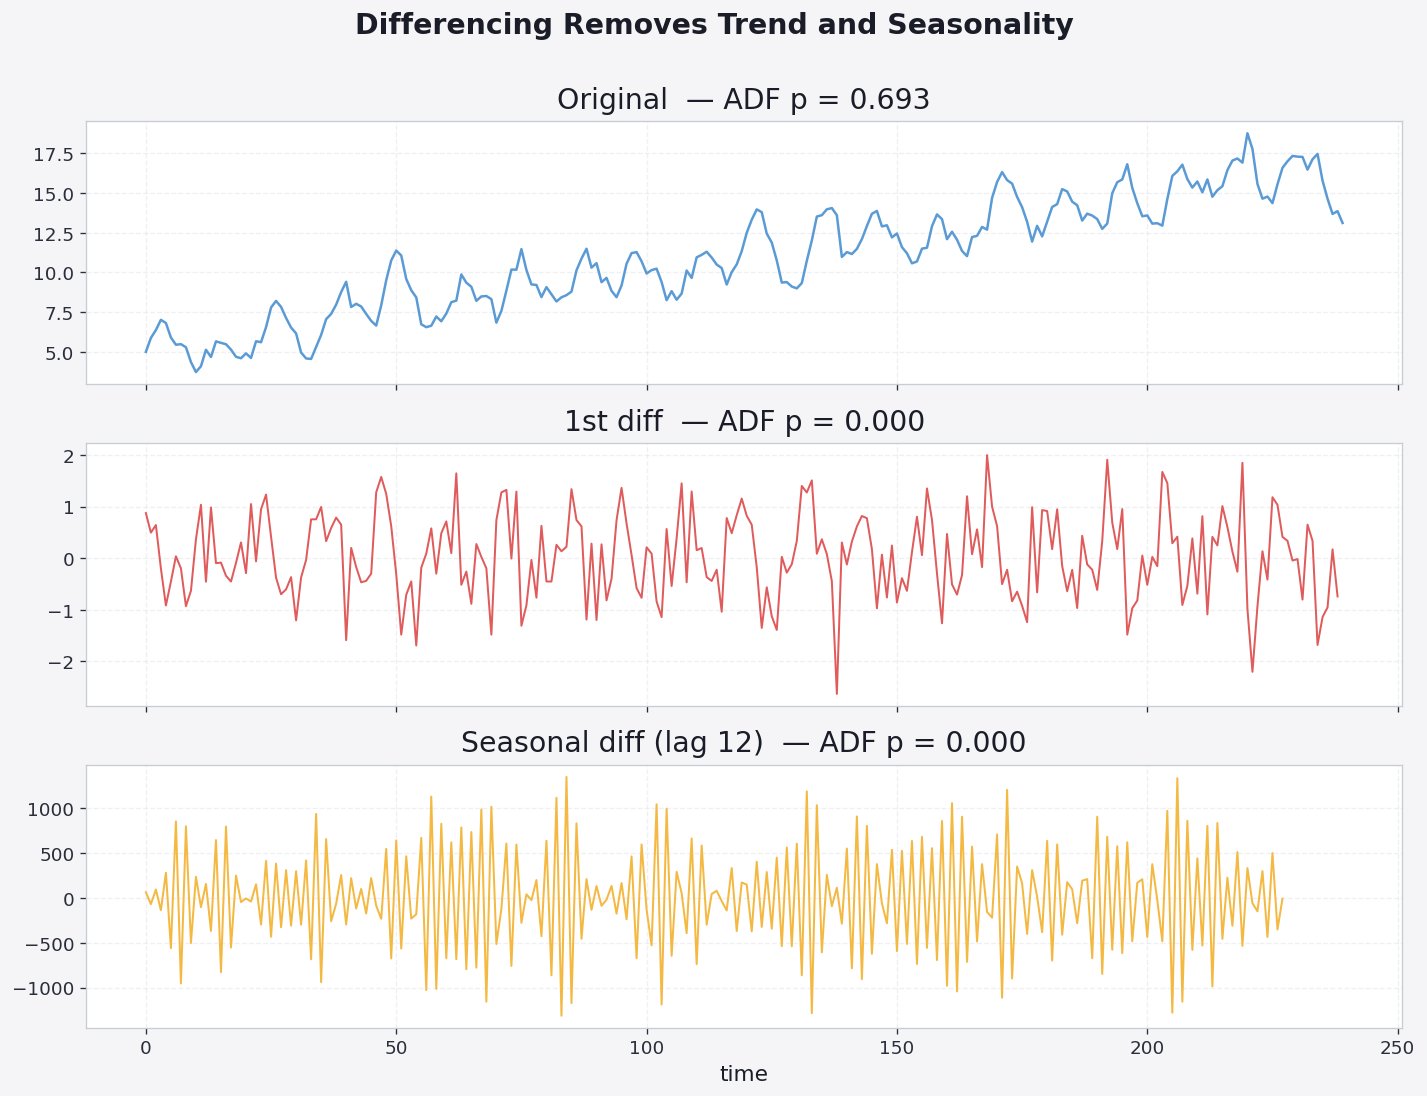

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
axes[0].plot(y, color=C0, lw=1.5); axes[0].set_title(f'Original  — ADF p = {adfuller(y)[1]:.3f}', pad=8)
axes[0].grid(True)
y1 = np.diff(y)
axes[1].plot(y1, color=C1, lw=1.2); axes[1].set_title(f'1st diff  — ADF p = {adfuller(y1)[1]:.3f}', pad=8)
axes[1].grid(True)
y12 = np.diff(y, n=12)   # seasonal differencing
axes[2].plot(y12, color=CB, lw=1.2); axes[2].set_title(f'Seasonal diff (lag 12)  — ADF p = {adfuller(y12)[1]:.3f}', pad=8)
axes[2].set_xlabel('time'); axes[2].grid(True)
fig.suptitle('Differencing Removes Trend and Seasonality', fontsize=17, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

---
## ACF & PACF — Picking $p$ and $q$

Rules of thumb on the **stationary** series:
- **AR(p)** → PACF cuts off after lag $p$, ACF tails off.
- **MA(q)** → ACF cuts off after lag $q$, PACF tails off.
- **ARMA(p, q)** → both tail off.

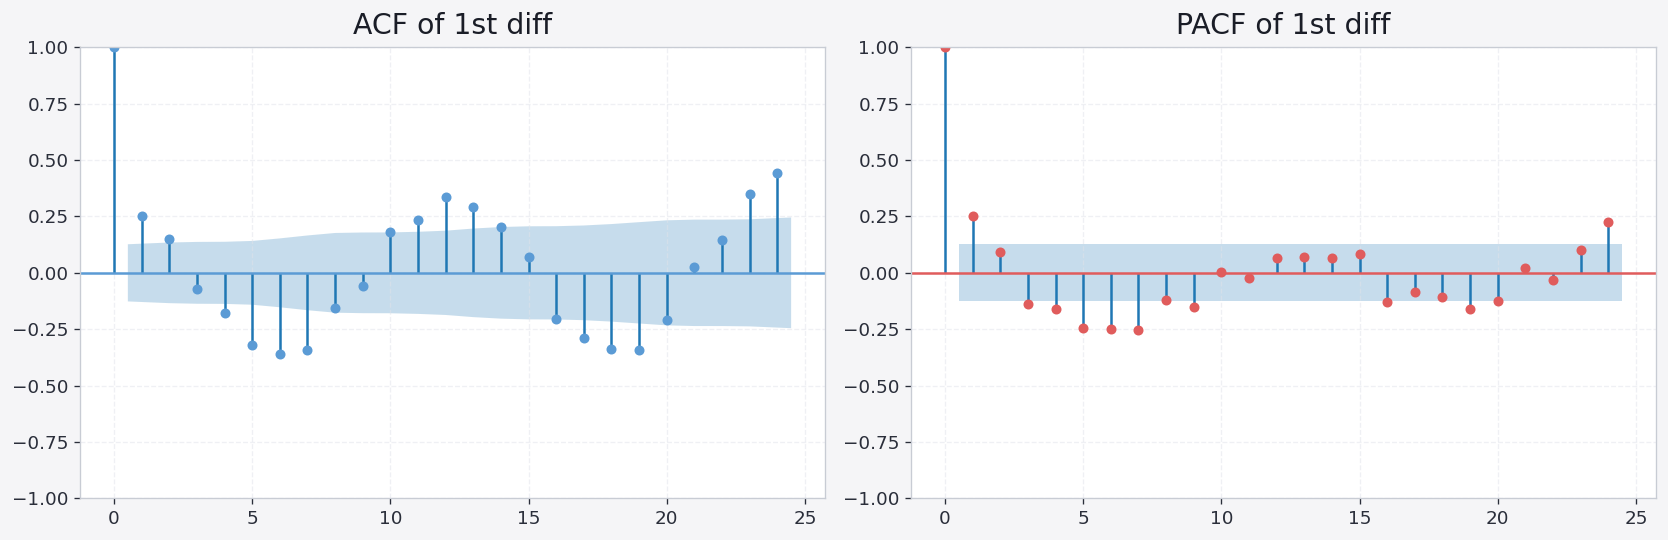

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
plot_acf(y1, ax=axes[0], lags=24, color=C0)
axes[0].set_title('ACF of 1st diff', pad=8); axes[0].grid(True)
plot_pacf(y1, ax=axes[1], lags=24, color=C1, method='ywm')
axes[1].set_title('PACF of 1st diff', pad=8); axes[1].grid(True)
plt.tight_layout(); plt.show()

---
## Fit & Forecast — ARIMA(2, 1, 1)

Reserve the last 36 points for testing. Fit on the rest, forecast with a 95 % prediction interval.

/home/sandeep/workspace/learn-ml/.venv/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/home/sandeep/workspace/learn-ml/.venv/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


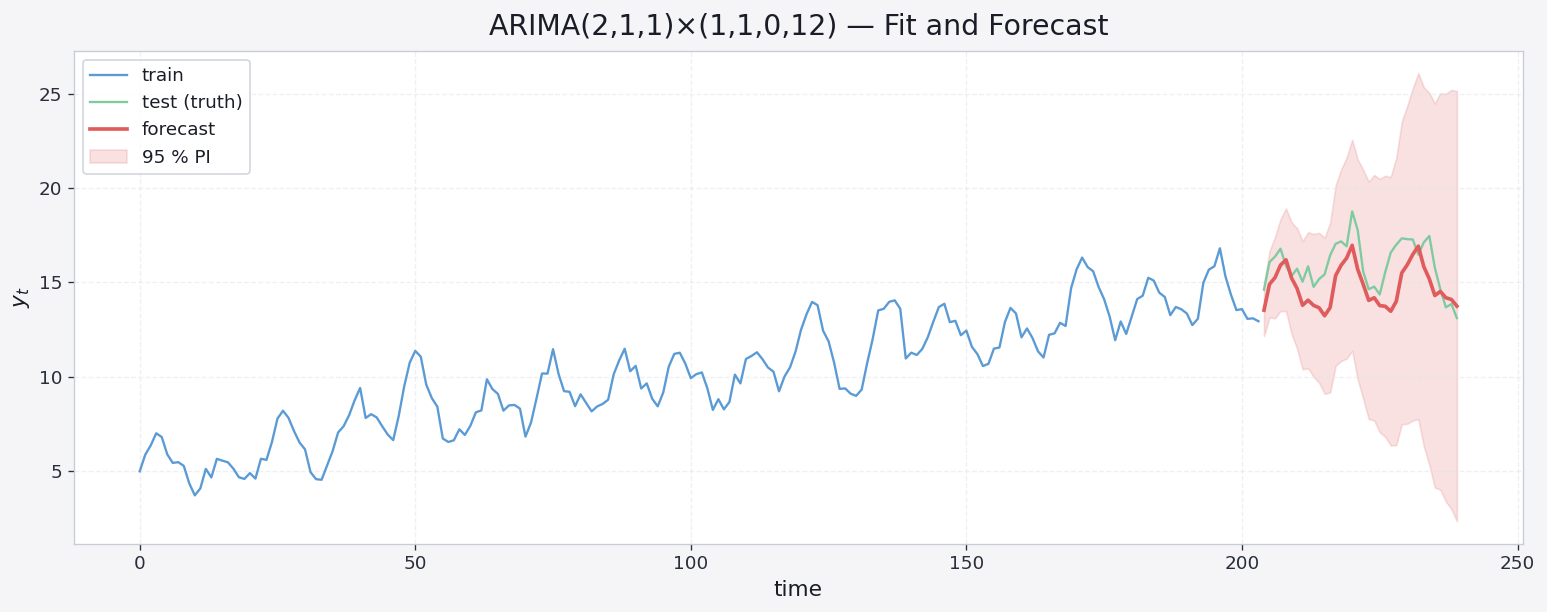

In [5]:
split = n - 36
train, test = y[:split], y[split:]
model = ARIMA(train, order=(2, 1, 1), seasonal_order=(1, 1, 0, 12)).fit()
fc = model.get_forecast(steps=36)
mean = fc.predicted_mean
ci = fc.conf_int(alpha=0.05)

fig, ax = plt.subplots(figsize=(13, 5.2))
ax.plot(np.arange(split), train, color=C0, lw=1.4, label='train')
ax.plot(np.arange(split, n), test, color=CM, lw=1.4, label='test (truth)')
ax.plot(np.arange(split, n), mean, color=C1, lw=2.2, label='forecast')
ax.fill_between(np.arange(split, n), ci[:, 0], ci[:, 1], color=C1, alpha=0.18, label='95 % PI')
ax.set_xlabel('time'); ax.set_ylabel('$y_t$')
ax.set_title('ARIMA(2,1,1)×(1,1,0,12) — Fit and Forecast', pad=10)
ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()

---
## Residual Diagnostics

If the model is good, residuals should look like **white noise**: ACF flat, normal-ish histogram, no obvious time pattern.

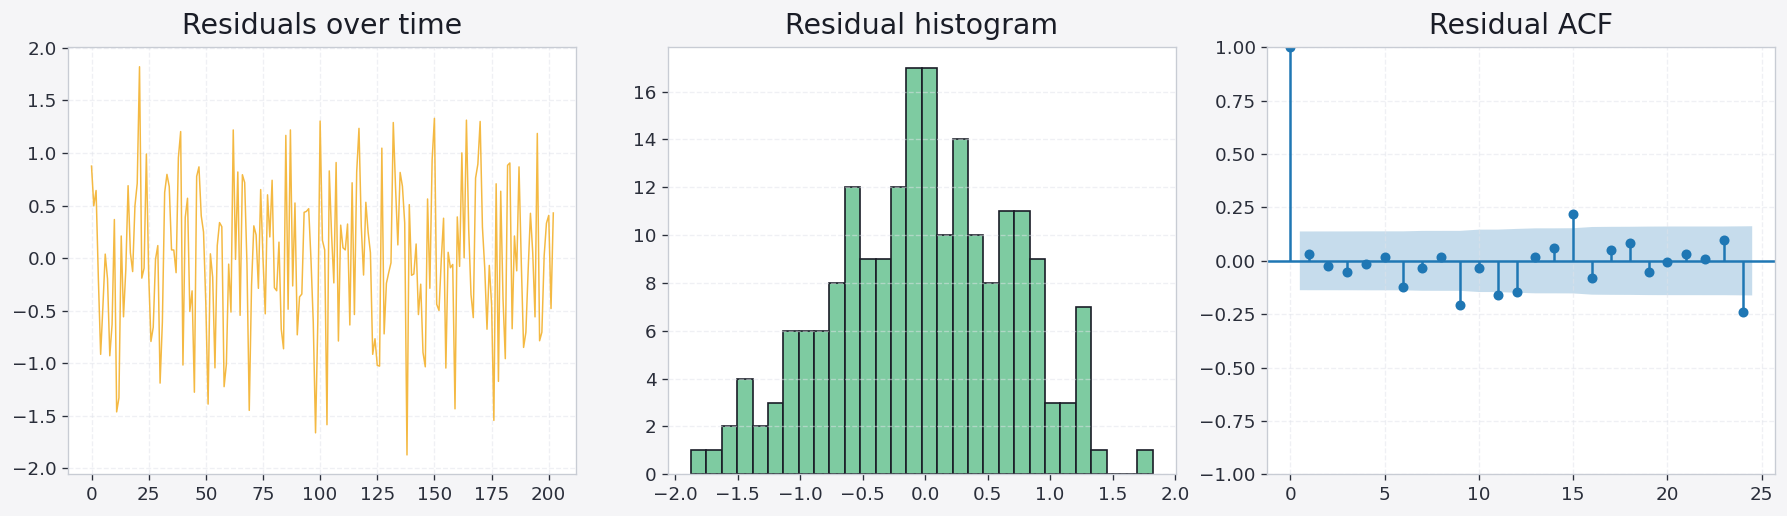

In [6]:
res = model.resid[1:]   # drop initial value
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
axes[0].plot(res, color=CB, lw=0.9); axes[0].set_title('Residuals over time', pad=8); axes[0].grid(True)
axes[1].hist(res, bins=30, color=CM, edgecolor='#1a1d27'); axes[1].set_title('Residual histogram', pad=8); axes[1].grid(True, axis='y')
plot_acf(res, ax=axes[2], lags=24); axes[2].set_title('Residual ACF', pad=8); axes[2].grid(True)
plt.tight_layout(); plt.show()

---
## ⚖️ When to use ARIMA — and when not to

| Situation | ARIMA | Prophet | LSTM | Naive seasonal |
|---|---|---|---|---|
| Short, low-frequency series | ✅ | ✅ | ❌ | ✅ baseline |
| Strong, well-defined seasonality | partial (SARIMA) | ✅ | partial | partial |
| Multiple related series | ❌ univariate | partial | ✅ | ❌ |
| Need uncertainty intervals | ✅ Gaussian | ✅ Bayesian | ❌ requires extra work | ❌ |

> ARIMA is the **classical first model** for any single time-series. Always benchmark against a seasonal naive forecast first.


---
## 🎯 Try this

1. **ACF/PACF reading.** Plot the autocorrelation and partial autocorrelation functions. Use them to read off plausible $(p, q)$ orders — should match what `auto_arima` finds.
2. **Differencing.** Try $d=0, 1, 2$. The ADF test should declare stationarity around the right $d$. Over-differencing introduces spurious MA terms.
3. **Residual diagnostics.** After fitting, plot residual ACF and run a Ljung-Box test. Significant autocorrelation = your model missed structure.


---
## Summary

| Concept | Description | Key Insight |
|---|---|---|
| AR($p$) | $y_t = \sum \phi_i y_{t-i} + \varepsilon_t$ | PACF cuts at $p$ |
| MA($q$) | $y_t = \sum \theta_j \varepsilon_{t-j} + \varepsilon_t$ | ACF cuts at $q$ |
| I($d$) | $\Delta^d y_t$ | Removes unit roots |
| Seasonal SARIMA | extra $(P,D,Q,m)$ | Models periodicity |
| Workflow | ADF → difference → ACF/PACF → fit → residuals | Box–Jenkins methodology |
| Strength | Tiny model; clean prediction intervals | Strong baseline for univariate series |
| Weakness | Linear; no exogenous regressors by default; manual order picking | Use `auto_arima` or Prophet for convenience |

**Bottom line:** ARIMA is the **stat-101 forecaster**. Difference until stationary, peek at ACF/PACF, fit, and check the residuals. If they look like noise you have a competitive baseline before any neural network is allowed in the room.